In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

Nuvem de palavras da coluna 'Marca' salva como 'nuvem_palavras_marca.png'


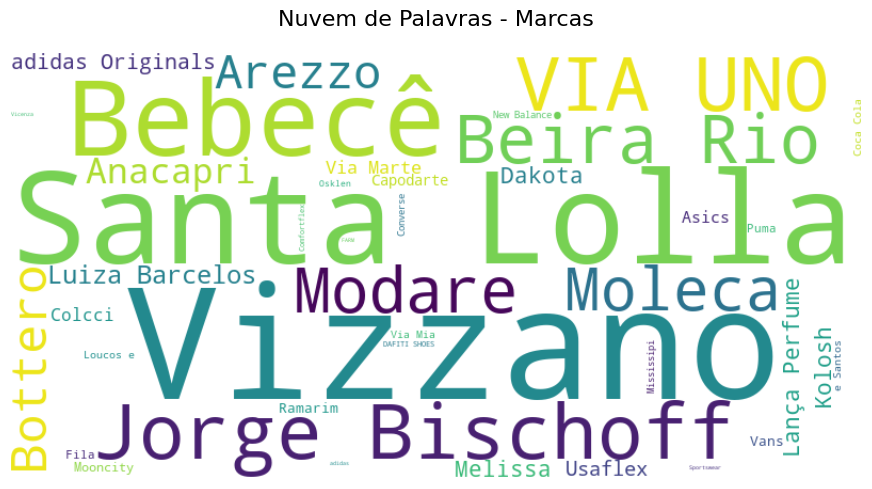

In [10]:
# 1. Descobre a pasta exata onde ESTE script (.py) está salvo
pasta_do_script =os.getcwd()

# 2. Sobe um nível a partir da pasta do script e entra em 'WebScrapping'
caminho_dados = os.path.abspath(os.path.join(pasta_do_script, 'WebScrapping', '20260412_DadosDafiti.csv')) # '..'

# 3. Carrega o arquivo
df = pd.read_csv(caminho_dados)
# --- NUVEM DE PALAVRAS PARA A COLUNA 'MARCA' ---
# Agrupa os textos removendo valores nulos
texto_marca = " ".join(df['Marca'].dropna().astype(str))

# Cria a nuvem de palavras para as marcas
wc_marca = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto_marca)

# Plota e salva a imagem das marcas
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.imshow(wc_marca, interpolation='bilinear')
ax1.set_title('Nuvem de Palavras - Marcas', fontsize=16, pad=20)
ax1.axis('off')
plt.tight_layout()
plt.savefig('nuvem_palavras_marca.png', dpi=300)
print("Nuvem de palavras da coluna 'Marca' salva como 'nuvem_palavras_marca.png'")


# # --- NUVEM DE PALAVRAS PARA A COLUNA 'COR' ---
# # Agrupa os textos removendo valores nulos
# texto_cor = " ".join(df['Cor'].dropna().astype(str))

# # Cria a nuvem de palavras para as cores
# wc_cor = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(texto_cor)

# # Plota e salva a imagem das cores
# fig2, ax2 = plt.subplots(figsize=(10, 5))
# ax2.imshow(wc_cor, interpolation='bilinear')
# ax2.set_title('Nuvem de Palavras - Cores', fontsize=16, pad=20)
# ax2.axis('off')
# plt.tight_layout()
# plt.savefig('nuvem_palavras_cor.png', dpi=300)
# print("Nuvem de palavras da coluna 'Cor' salva como 'nuvem_palavras_cor.png'")

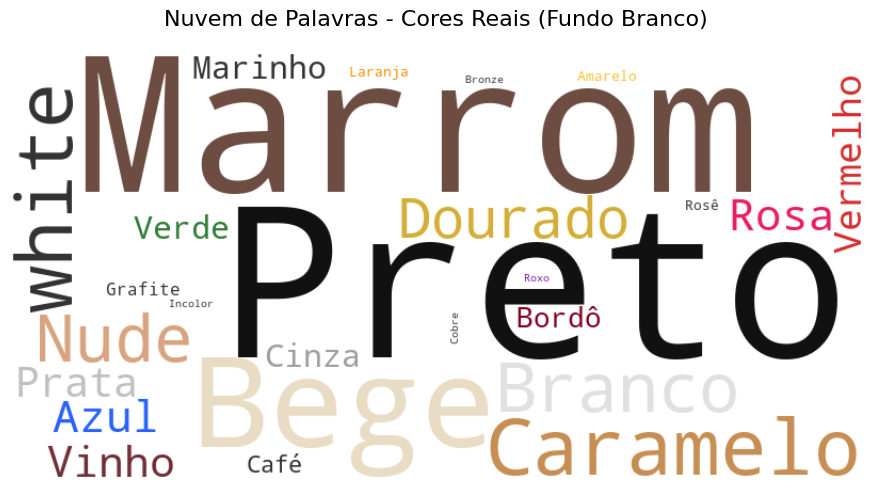

In [14]:

# Agrupa os textos da coluna 'Cor' removendo valores nulos
texto_cor = " ".join(df['Cor'].dropna().astype(str))

# 2. Dicionário Avançado de Cores (Tons precisos baseados em HEX e CSS)
mapa_de_cores = {
    'preto': '#111111',          # preto menos "estourado" que #000000
    'branco': '#E0E0E0',
    'off-white': '#F5F5F0',
    'nude': '#D8A47F',

    'azul marinho': '#1A237E',
    'azul claro': '#81D4FA',
    'azul celeste': '#4FC3F7',
    'azul': '#2962FF',

    'verde militar': '#4B5320',
    'verde oliva': '#6B8E23',
    'verde claro': '#8BCF7B',
    'verde água': '#3CBDB1',
    'verde': '#2E7D32',

    'mostarda': '#D4A017',
    'amarelo': '#FBC02D',

    'vinho': '#722F37',
    'bordô': '#800020',
    'vermelho': '#D32F2F',

    'rosa claro': '#F8BBD0',
    'rosa choque': '#FF1493',
    'pink': '#EC407A',
    'rosa': '#E91E63',

    'roxo': '#7B1FA2',
    'lilás': '#C8A2D1',
    'lilas': '#C8A2D1',

    'marrom': '#6D4C41',
    'caramelo': '#C68E52',
    'bege': '#E8DCC4',

    'cinza chumbo': '#424242',
    'cinza': '#9E9E9E',
    'prata': '#C0C0C0',

    'laranja': '#FB8C00',
    'coral': '#FF6F61',
    'dourado': '#D4AF37'
}

# Ordena as chaves do dicionário por tamanho (da maior para a menor).
# Isso garante que "Azul Marinho" seja testado ANTES de "Azul".
cores_ordenadas = sorted(mapa_de_cores.keys(), key=len, reverse=True)

# 3. Função customizada para aplicar a cor exata
def cor_por_palavra(word, font_size, position, orientation, random_state=None, **kwargs):
    palavra_min = word.lower()
    
    # Procura a cor exata na nossa lista ordenada
    for cor_pt in cores_ordenadas:
        if cor_pt in palavra_min:
            return mapa_de_cores[cor_pt]
            
    # Se for uma cor que não está no dicionário, pinta de um cinza escuro genérico
    return '#333333' 

# 4. Cria a nuvem de palavras
wc_cor = WordCloud(
    width=800, 
    height=400, 
    background_color='white',    # Fundo branco conforme solicitado
    collocations=False,          # Evita que a biblioteca junte palavras iguais (ex: "Preto Preto")
    color_func=cor_por_palavra
).generate(texto_cor)

# 5. Plota a imagem
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(wc_cor, interpolation='bilinear')
ax.set_title('Nuvem de Palavras - Cores Reais (Fundo Branco)', fontsize=16, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()

Gráfico de Boxplot salvo com sucesso como 'boxplot_precos_dafiti.png'


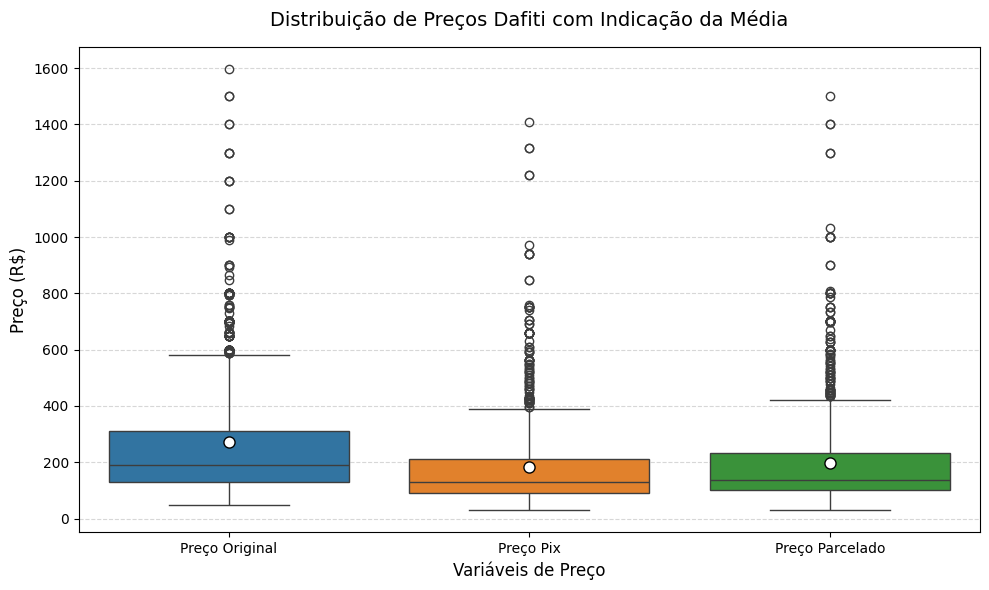

In [7]:
# Colunas de preço alvo da análise
colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']

# 2. Tratamento e Limpeza dos Dados
# Remove o símbolo 'R$', pontos de milhar e substitui a vírgula decimal por ponto.
for col in colunas_preco:
    if col in df.columns:
        if df[col].dtype == 'object':  # Aplica apenas se a coluna contiver texto
            df[col] = df[col].astype(str).str.replace('R$', '', regex=False)
            df[col] = df[col].str.replace('.', '', regex=False)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Construção do Gráfico de Boxplot
fig, ax = plt.subplots(figsize=(10, 6))

# showmeans=True ativa o cálculo e exibição da média amostral
# meanprops customiza a aparência do indicador da média (uma bolinha branca com contorno preto)
sns.boxplot(
    data=df[colunas_preco], 
    ax=ax, 
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)

# Customizações estéticas do gráfico
ax.set_title('Distribuição de Preços Dafiti com Indicação da Média', fontsize=14, pad=15)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.set_xlabel('Variáveis de Preço', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)  # Linhas de grade sutis no eixo Y

# Ajusta o layout e salva o gráfico em arquivo
plt.tight_layout()
plt.savefig('boxplot_precos_dafiti.png', dpi=300)
print("Gráfico de Boxplot salvo com sucesso como 'boxplot_precos_dafiti.png'")

C:\Users\catit\AppData\Local\Temp\ipykernel_18620\3552133510.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


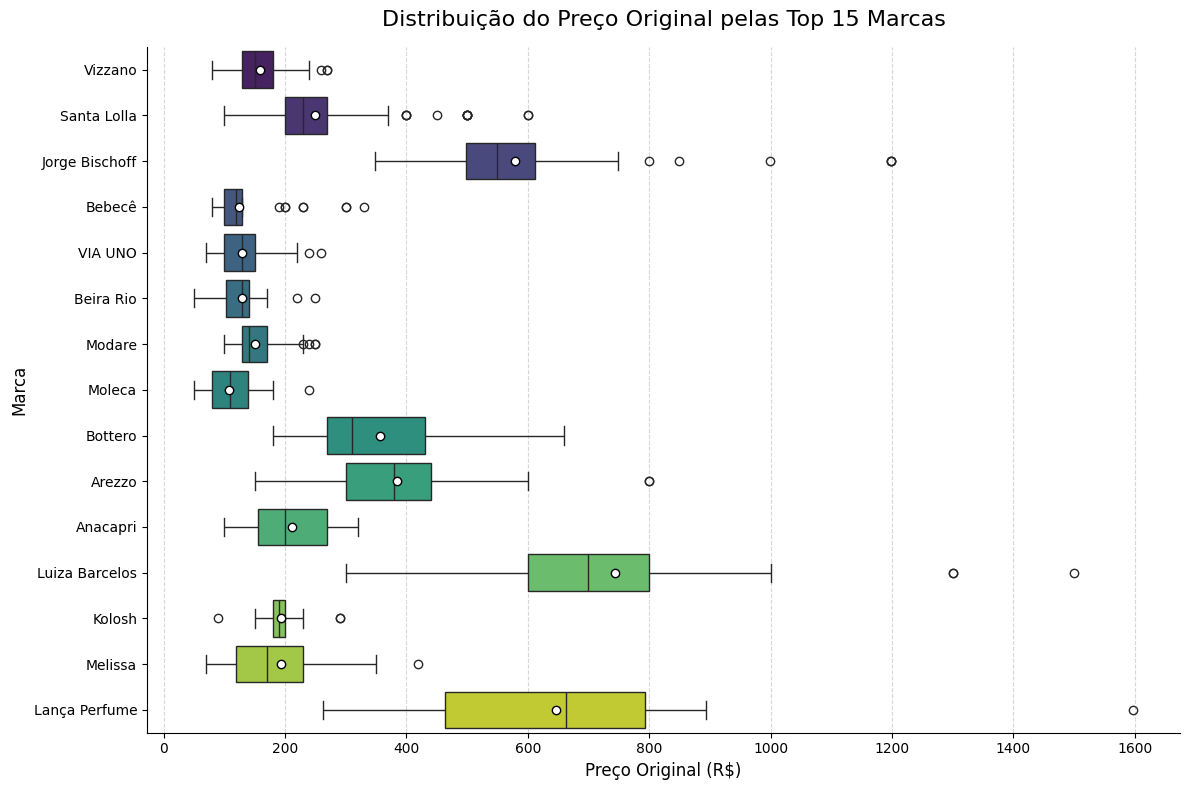

Processando bow.csv...


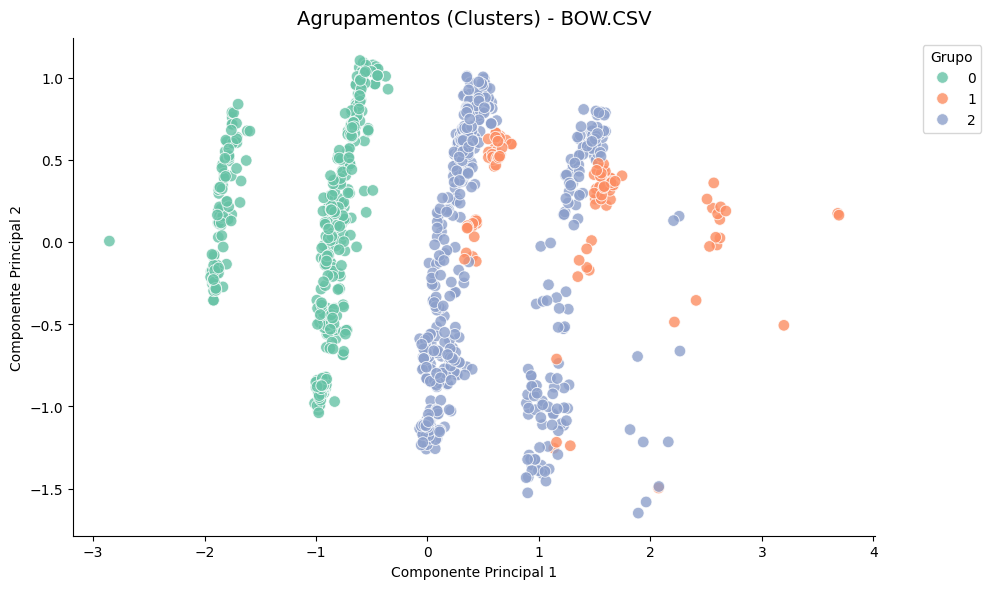

In [32]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

# Oculta alguns avisos de atualização da biblioteca sklearn para limpar o terminal
warnings.filterwarnings('ignore')

arquivos = ['bow.csv']#, 'tfidf.csv']

# Defini 4 grupos (clusters) como ponto de partida. Você pode aumentar ou diminuir esse número!
num_grupos = 3 

# Prepara a figura com 2 gráficos lado a lado
fig, ax = plt.subplots(figsize=(10, 6)) #fig, axes = plt.subplots(1, 2, figsize=(16, 6))
try:
    # 2. Carregamento e Limpeza
    # Certifique-se de que a variável 'pasta_atual' já foi definida no seu código (ex: pasta_atual = os.getcwd())
    caminho_dados = os.path.abspath(os.path.join(pasta_atual, 'dados', arquivo))
    print(f"Processando {arquivo}...")
    df = pd.read_csv(caminho_dados)
    
    # Remove a coluna de índice do pandas caso ela tenha sido exportada no CSV
    if 'Unnamed: 0' in df.columns:
        df = df.drop('Unnamed: 0', axis=1)
        
    # Garante que usaremos apenas as colunas numéricas (frequência das palavras) e remove valores nulos
    X = df.select_dtypes(include=['number']).fillna(0)
    
    # 3. Algoritmo K-Means (O Agrupamento real)
    kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(X)
    
    # 4. Algoritmo PCA (Redução de Dimensionalidade para o Gráfico)
    pca = PCA(n_components=2, random_state=42)
    X_reduzido = pca.fit_transform(X)
    
    # 5. Plotagem do Gráfico
    sns.scatterplot(
        x=X_reduzido[:, 0], 
        y=X_reduzido[:, 1], 
        hue=clusters,         # Pinta os pontos baseados no grupo em que o KMeans os colocou
        palette='Set2',       # Paleta de cores suave e legível
        ax=ax,                # Passa o eixo único que criamos lá em cima
        s=70,                 # Tamanho das bolinhas
        alpha=0.8,            # Transparência para ver sobreposições
        legend='full'
    )
    
    # Customizações estéticas
    ax.set_title(f'Agrupamentos (Clusters) - {arquivo.upper()}', fontsize=14, pad=10)
    ax.set_xlabel('Componente Principal 1', fontsize=10)
    ax.set_ylabel('Componente Principal 2', fontsize=10)
    
    # Arruma a legenda
    ax.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

except FileNotFoundError:
    print(f"Erro: O arquivo {arquivo} não foi encontrado em {caminho_dados}.")

sns.despine()
plt.tight_layout()
plt.show()

In [33]:
df_orig = df.copy()
# Adiciona a resposta do algoritmo (0, 1 ou 2) como uma nova coluna na base original
# (Isso assume que o bow.csv foi gerado a partir da base original sem embaralhar as linhas)
df_orig['Cluster_BOW'] = clusters

print("="*40)
print(" RELATÓRIO DE PERFIL DOS GRUPOS (K-MEANS)")
print("="*40)

# Faz um loop (0, 1 e 2) para analisar cada grupo separadamente
for i in range(num_grupos):
    print(f"\n🟢 PERFIL DO GRUPO {i}")
    print("-" * 30)
    
    # Filtra a base original para ter apenas os produtos desse grupo específico
    df_grupo = df_orig[df_orig['Cluster_BOW'] == i]
    
    print(f"Total de produtos no grupo: {len(df_grupo)}")
    
    # --- Cálculo da Média de Preços ---
    print("\n💰 Médias de Preço:")
    for col in colunas_preco:
        if col in df_grupo.columns:
            media = df_grupo[col].mean()
            # Formata a string para exibir como moeda (R$ 0.00)
            print(f"  > {col}: R$ {media:.2f}")
            
    # --- Identificação do Top 5 Cores ---
    if 'Cor' in df_grupo.columns:
        print("\n🎨 Top 5 Cores Mais Comuns:")
        # value_counts() conta as aparições, head(5) pega as 5 primeiras
        top_cores = df_grupo['Cor'].value_counts().head(5) 
        for cor, quantidade in top_cores.items():
            print(f"  > {cor}: {quantidade} unidades")

 RELATÓRIO DE PERFIL DOS GRUPOS (K-MEANS)

🟢 PERFIL DO GRUPO 0
------------------------------
Total de produtos no grupo: 418

💰 Médias de Preço:


TypeError: Could not convert string 'R$ 169,99R$ 749,99R$ 69,90R$ 169,90R$ 69,90R$ 99,90R$ 139,90R$ 89,90R$ 119,99R$ 139,99R$ 149,99R$ 129,90R$ 119,99R$ 99,99R$ 139,99R$ 259,99R$ 149,90R$ 139,99R$ 129,99R$ 119,99R$ 119,99R$ 99,99R$ 99,90R$ 69,99R$ 89,99R$ 114,99R$ 129,99R$ 99,90R$ 119,99R$ 219,99R$ 129,99R$ 119,99R$ 269,99R$ 89,90R$ 99,99R$ 109,99R$ 99,99R$ 99,99R$ 169,90R$ 99,90R$ 279,99R$ 119,99R$ 244,99R$ 99,90R$ 99,99R$ 119,99R$ 129,99R$ 209,99R$ 99,99R$ 549,99R$ 139,90R$ 449,00R$ 749,99R$ 589,00R$ 99,99R$ 229,90R$ 129,99R$ 79,90R$ 329,99R$ 129,90R$ 94,99R$ 299,90R$ 149,99R$ 109,99R$ 189,90R$ 129,99R$ 79,99R$ 589,00R$ 109,99R$ 129,90R$ 119,99R$ 199,99R$ 129,90R$ 129,90R$ 139,90R$ 99,90R$ 249,90R$ 379,00R$ 89,99R$ 119,99R$ 450,00R$ 189,90R$ 219,99R$ 149,99R$ 139,90R$ 179,99R$ 179,90R$ 199,90R$ 159,90R$ 129,90R$ 129,99R$ 550,00R$ 599,99R$ 79,99R$ 159,99R$ 89,99R$ 129,99R$ 139,99R$ 84,99R$ 139,99R$ 499,00R$ 109,90R$ 189,90R$ 249,90R$ 549,00R$ 69,99R$ 159,90R$ 469,00R$ 129,99R$ 269,90R

📦 Produtos na base original: 1200
🧠 Produtos no Bag of Words: 1101

🔍 Iniciando 'Modo Detetive' para recuperar o alinhamento das linhas perdidas...
⚠️ AVISO: Alinhando de forma forçada pelo topo.


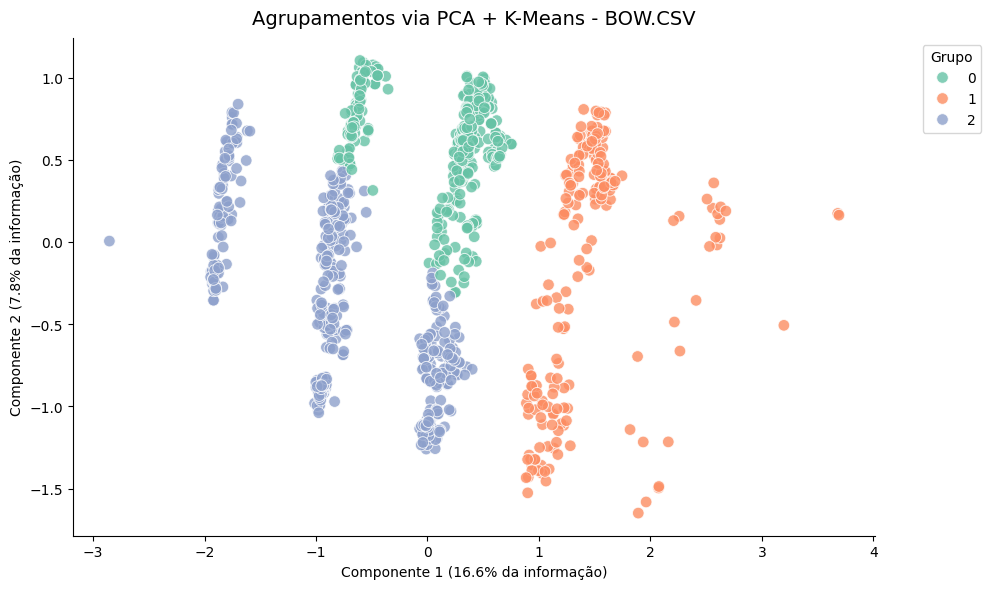


 🔎 ANÁLISE: O QUE OS EIXOS DO PCA REPRESENTAM?
No texto, o PCA agrupa palavras que costumam aparecer juntas.

🔹 EIXO X (COMPONENTE 1):
   > Palavras que levam o produto para a DIREITA/CIMA:
      - 'palavras_unicas' (Peso: 0.925)
      - 'bow_feminina' (Peso: 0.214)
      - 'bow_salto' (Peso: 0.138)
      - 'bow_cano' (Peso: 0.124)
      - 'bow_bota' (Peso: 0.114)
      - 'bow_baixo' (Peso: 0.087)
      - 'bow_lolla' (Peso: 0.054)
   > Palavras que levam o produto para a ESQUERDA/BAIXO:
      - 'bow_tenis' (Peso: -0.077)
      - 'bow_vizzano' (Peso: -0.040)
      - 'bow_preto' (Peso: -0.031)
      - 'bow_mocassim' (Peso: -0.030)
      - 'bow_sapatilha' (Peso: -0.028)
      - 'bow_anacapri' (Peso: -0.026)
      - 'bow_modare' (Peso: -0.026)

🔹 EIXO Y (COMPONENTE 2):
   > Palavras que levam o produto para a DIREITA/CIMA:
      - 'bow_feminina' (Peso: 0.531)
      - 'bow_sandalia' (Peso: 0.318)
      - 'bow_preta' (Peso: 0.149)
      - 'bow_rasteira' (Peso: 0.145)
      - 'bow_tiras' (Pe

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

# Configurações Iniciais
pasta_atual = os.getcwd()
arquivo = 'bow.csv'
num_grupos = 3 

# =====================================================================
# 1. CARREGAMENTO E LIMPEZA DA BASE ORIGINAL 
# =====================================================================
caminho_original = os.path.abspath(os.path.join(pasta_atual,'WebScrapping', '20260412_DadosDafiti.csv'))
df_orig = pd.read_csv(caminho_original)

colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']
for col in colunas_preco:
    if col in df_orig.columns:
        df_orig[col] = df_orig[col].astype(str).replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
        df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')


# =====================================================================
# 2. MODO DETETIVE, PCA, K-MEANS E GRÁFICO
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

try:
    caminho_dados = os.path.abspath(os.path.join(pasta_atual, 'dados', arquivo))
    df_bow = pd.read_csv(caminho_dados)
    
    print(f"📦 Produtos na base original: {len(df_orig)}")
    print(f"🧠 Produtos no Bag of Words: {len(df_bow)}\n")
    
    df_alinhado = None
    
    # --- O MODO DETETIVE ENTRA EM AÇÃO ---
    if len(df_orig) == len(df_bow):
        df_alinhado = df_orig.copy()
    else:
        print("🔍 Iniciando 'Modo Detetive' para recuperar o alinhamento das linhas perdidas...")
        
        if 'Unnamed: 0' in df_bow.columns:
            rgs = df_bow['Unnamed: 0'].values
            if rgs.max() < len(df_orig):
                df_alinhado = df_orig.iloc[rgs].copy()
                print("✔️ Mistério resolvido! Usamos a coluna de ID para alinhar os produtos.")
        
        if df_alinhado is None:
            for col in df_orig.select_dtypes(include=['object']).columns:
                if len(df_orig.dropna(subset=[col])) == len(df_bow):
                    df_alinhado = df_orig.dropna(subset=[col]).copy()
                    print(f"✔️ Mistério resolvido! Linhas vazias na coluna '{col}' foram excluídas.")
                    break
        
        if df_alinhado is None:
            if len(df_orig.drop_duplicates()) == len(df_bow):
                df_alinhado = df_orig.drop_duplicates().copy()
                print("✔️ Mistério resolvido! As linhas apagadas eram duplicatas exatas.")
                
        if df_alinhado is None:
            print("⚠️ AVISO: Alinhando de forma forçada pelo topo.")
            df_alinhado = df_orig.iloc[:len(df_bow)].copy()
    
    # Prepara a base de palavras
    if 'Unnamed: 0' in df_bow.columns:
        df_bow = df_bow.drop('Unnamed: 0', axis=1)
        
    X = df_bow.select_dtypes(include=['number']).fillna(0)
    nomes_das_palavras = X.columns
    
    # ---------------------------------------------------------
    # [NOVIDADE]: O PCA RODA PRIMEIRO
    # ---------------------------------------------------------
    pca = PCA(n_components=2, random_state=42)
    X_reduzido = pca.fit_transform(X)
    
    # Agrupamento K-Means (agora aprende com o PCA e não com o BoW bruto)
    kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(X_reduzido)
    
    # Sincroniza os resultados
    df_alinhado['Cluster_BOW'] = clusters
    
    # Plotagem do Gráfico
    sns.scatterplot(
        x=X_reduzido[:, 0], 
        y=X_reduzido[:, 1], 
        hue=clusters,         
        palette='Set2',       
        ax=ax,                
        s=70,                 
        alpha=0.8,            
        legend='full'
    )
    
    ax.set_title(f'Agrupamentos via PCA + K-Means - {arquivo.upper()}', fontsize=14, pad=10)
    ax.set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da informação)', fontsize=10)
    ax.set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da informação)', fontsize=10)
    ax.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')

except FileNotFoundError:
    print(f"Erro: O arquivo {arquivo} não foi encontrado.")

sns.despine()
plt.tight_layout()
plt.show() 


# =====================================================================
# 3. ANÁLISE DOS COMPONENTES DO PCA (O QUE ELES SIGNIFICAM?)
# =====================================================================
if 'pca' in locals():
    print("\n" + "="*40)
    print(" 🔎 ANÁLISE: O QUE OS EIXOS DO PCA REPRESENTAM?")
    print("="*40)
    print("No texto, o PCA agrupa palavras que costumam aparecer juntas.")
    
    for i, component in enumerate(pca.components_):
        # Pega as 7 palavras com maior peso positivo e negativo neste eixo
        top_pos = component.argsort()[-7:][::-1] 
        top_neg = component.argsort()[:7] 
        
        print(f"\n🔹 EIXO X (COMPONENTE {i+1}):" if i == 0 else f"\n🔹 EIXO Y (COMPONENTE {i+1}):")
        
        print("   > Palavras que levam o produto para a DIREITA/CIMA:")
        for idx in top_pos:
            print(f"      - '{nomes_das_palavras[idx]}' (Peso: {component[idx]:.3f})")
            
        print("   > Palavras que levam o produto para a ESQUERDA/BAIXO:")
        for idx in top_neg:
            print(f"      - '{nomes_das_palavras[idx]}' (Peso: {component[idx]:.3f})")


# =====================================================================
# 4. ANÁLISE DE NEGÓCIO DOS GRUPOS (RELATÓRIO FINAL)
# =====================================================================
if df_alinhado is not None:
    print("\n" + "="*40)
    print(" RELATÓRIO DE PERFIL DOS GRUPOS")
    print("="*40)

    for i in range(num_grupos):
        print(f"\n🟢 PERFIL DO GRUPO {i}")
        print("-" * 30)
        
        df_grupo = df_alinhado[df_alinhado['Cluster_BOW'] == i]
        print(f"Total de produtos no grupo: {len(df_grupo)}")
        
        print("\n💰 Médias de Preço:")
        for col in colunas_preco:
            if col in df_grupo.columns:
                media = df_grupo[col].mean()
                print(f"  > {col}: R$ {media:.2f}")
                
        if 'Cor' in df_grupo.columns:
            print("\n🎨 Top 5 Cores Mais Comuns:")
            top_cores = df_grupo['Cor'].value_counts().head(5) 
            for cor, quantidade in top_cores.items():
                print(f"  > {cor}: {quantidade} unidades")

Processando a base original 20260412_DadosDafiti.csv...

📦 Produtos carregados na base original: 1200


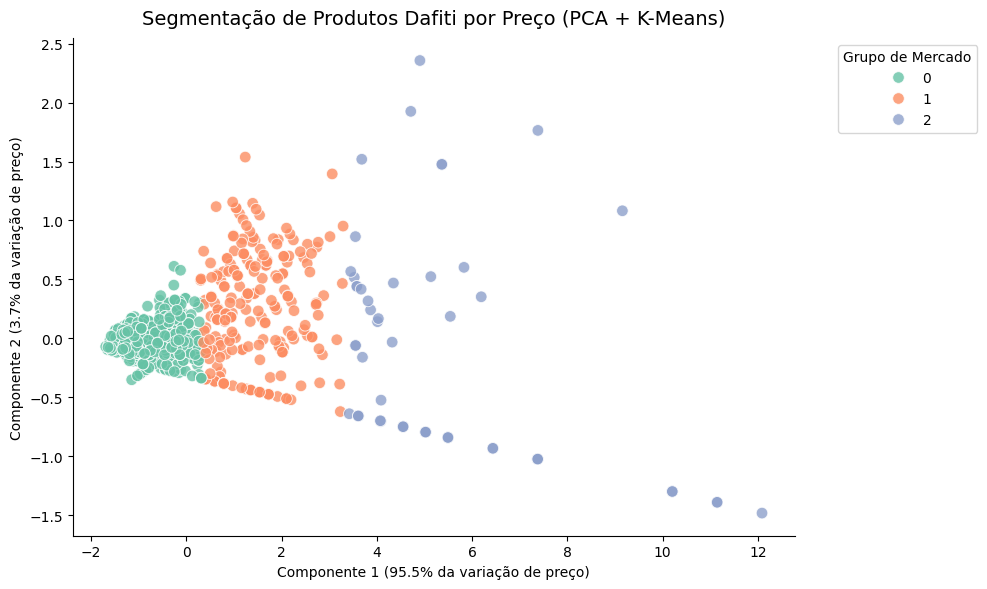


 🔎 ANÁLISE DO PCA: O QUE OS EIXOS REPRESENTAM?
Como estamos avaliando preços, veja qual variável puxa o gráfico para cada lado:

🔹 COMPONENTE 1 (Eixo X):
   > Preço Parcelado: +0.583 -> Força Positiva (Direita/Cima)
   > Preço Pix: +0.581 -> Força Positiva (Direita/Cima)
   > Preço Original: +0.568 -> Força Positiva (Direita/Cima)

🔹 COMPONENTE 2 (Eixo Y):
   > Preço Original: +0.821 -> Força Positiva (Direita/Cima)
   > Preço Parcelado: -0.358 -> Força Negativa (Esquerda/Baixo)
   > Preço Pix: -0.444 -> Força Negativa (Esquerda/Baixo)

 RELATÓRIO DE PERFIL DOS GRUPOS (POR PREÇO)

🟢 PERFIL DO GRUPO 0 - Categoria: Básico (Entrada)
---------------------------------------------
Total de produtos no segmento: 896 (74.7%)

💰 Ticket Médio do Segmento:
  > Preço Original: R$ 167.98
  > Preço Pix: R$ 114.10
  > Preço Parcelado: R$ 122.42

🎨 Top 3 Cores do Segmento:
  > Preto: 248 unidades
  > Marrom: 189 unidades
  > Bege: 83 unidades

🏷️ Top 3 Marcas do Segmento:
  > Vizzano: 157 unidades
  

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

# Configurações Iniciais
pasta_atual = os.getcwd()
arquivo = '20260412_DadosDafiti.csv'
num_grupos = 3 

# =====================================================================
# 1. CARREGAMENTO E LIMPEZA DA BASE
# =====================================================================
print(f"Processando a base original {arquivo}...\n")
caminho_original = os.path.abspath(os.path.join(pasta_atual, 'WebScrapping', arquivo))

try:
    df_orig = pd.read_csv(caminho_original)
    
    # Limpeza cega e forçada de preços
    colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']
    colunas_disponiveis = [] # Guarda quais colunas de preço realmente existem na base
    
    for col in colunas_preco:
        if col in df_orig.columns:
            df_orig[col] = df_orig[col].astype(str).replace(r'[^\d,]', '', regex=True).str.replace(',', '.', regex=False)
            df_orig[col] = pd.to_numeric(df_orig[col], errors='coerce')
            colunas_disponiveis.append(col)
            
    print(f"📦 Produtos carregados na base original: {len(df_orig)}")
    
except FileNotFoundError:
    print(f"Erro: O arquivo {arquivo} não foi encontrado no caminho especificado.")
    # Interrompe o script se não achar o arquivo
    raise SystemExit


# =====================================================================
# 2. PREPARAÇÃO, PCA, K-MEANS E GRÁFICO
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Usaremos as colunas de preço como a base da nossa inteligência
X = df_orig[colunas_disponiveis].copy()

# Passo A: O K-Means e o PCA não lidam bem com valores nulos (NaN).
# Preenchemos produtos que não têm algum dos preços com a mediana para não perder a linha
imputer = SimpleImputer(strategy='median')
X_imputado = imputer.fit_transform(X)

# Passo B: Padronização (Escala todos os preços para a mesma proporção matemática)
# Isso é obrigatório quando usamos PCA em variáveis contínuas (dinheiro, peso, altura, etc.)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X_imputado)

# Passo C: O PCA entra em ação (Reduz os 3 tipos de preços a 2 Componentes abstratos)
pca = PCA(n_components=2, random_state=42)
X_reduzido = pca.fit_transform(X_padronizado)

# Passo D: Agrupamento K-Means nos dados reduzidos pelo PCA
kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_reduzido)

# Salva o resultado do agrupamento de volta na base de dados
df_orig['Cluster_Preco'] = clusters

# Passo E: Plotagem do Gráfico
sns.scatterplot(
    x=X_reduzido[:, 0], 
    y=X_reduzido[:, 1], 
    hue=clusters,         
    palette='Set2',       
    ax=ax,                
    s=70,                 
    alpha=0.8,            
    legend='full'
)

ax.set_title('Segmentação de Produtos Dafiti por Preço (PCA + K-Means)', fontsize=14, pad=10)
ax.set_xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variação de preço)', fontsize=10)
ax.set_ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variação de preço)', fontsize=10)
ax.legend(title='Grupo de Mercado', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show() 


# =====================================================================
# 3. ANÁLISE DOS COMPONENTES DO PCA
# =====================================================================
print("\n" + "="*40)
print(" 🔎 ANÁLISE DO PCA: O QUE OS EIXOS REPRESENTAM?")
print("="*40)
print("Como estamos avaliando preços, veja qual variável puxa o gráfico para cada lado:")

for i, component in enumerate(pca.components_):
    print(f"\n🔹 COMPONENTE {i+1} (Eixo {'X' if i==0 else 'Y'}):")
    # Zippa o nome da coluna com o peso dela no eixo atual e ordena
    pesos = sorted(zip(colunas_disponiveis, component), key=lambda x: x[1], reverse=True)
    
    for nome_coluna, peso in pesos:
        direcao = "Positiva (Direita/Cima)" if peso > 0 else "Negativa (Esquerda/Baixo)"
        print(f"   > {nome_coluna}: {peso:+.3f} -> Força {direcao}")


# =====================================================================
# 4. RELATÓRIO FINAL DE NEGÓCIO
# =====================================================================
print("\n" + "="*40)
print(" RELATÓRIO DE PERFIL DOS GRUPOS (POR PREÇO)")
print("="*40)

# Lógica extra: Ordenar os grupos do mais barato para o mais caro antes de imprimir!
# Calcula a média do Preço Original por grupo para saber quem é o barato, intermediário e caro
medias_grupo = df_orig.groupby('Cluster_Preco')['Preço Original'].mean().sort_values()
ordem_de_preco = medias_grupo.index

for posicao, id_grupo in enumerate(ordem_de_preco):
    # Nomenclatura automática baseada no preço
    if num_grupos == 3:
        nome_perfil = ["Básico (Entrada)", "Intermediário", "Premium (Luxo)"][posicao]
    else:
        nome_perfil = f"Nível de Preço {posicao+1}"
        
    print(f"\n🟢 PERFIL DO GRUPO {id_grupo} - Categoria: {nome_perfil}")
    print("-" * 45)
    
    df_grupo = df_orig[df_orig['Cluster_Preco'] == id_grupo]
    print(f"Total de produtos no segmento: {len(df_grupo)} ({len(df_grupo)/len(df_orig)*100:.1f}%)")
    
    print("\n💰 Ticket Médio do Segmento:")
    for col in colunas_disponiveis:
        media = df_grupo[col].mean()
        print(f"  > {col}: R$ {media:.2f}")
            
    if 'Cor' in df_grupo.columns:
        print("\n🎨 Top 3 Cores do Segmento:")
        top_cores = df_grupo['Cor'].value_counts().head(3) 
        for cor, quantidade in top_cores.items():
            print(f"  > {cor}: {quantidade} unidades")
            
    if 'Marca' in df_grupo.columns:
        print("\n🏷️ Top 3 Marcas do Segmento:")
        top_marcas = df_grupo['Marca'].value_counts().head(3) 
        for marca, quantidade in top_marcas.items():
            print(f"  > {marca}: {quantidade} unidades")

# ----------------------------------------------------------------------------------

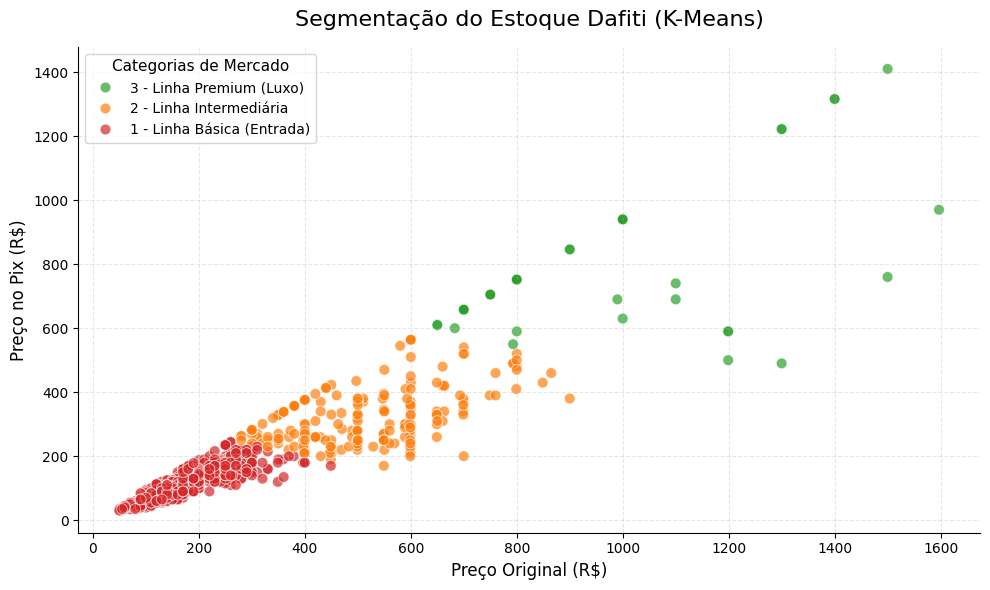

=== RELATÓRIO DO K-MEANS ===
Média de preços encontrada para cada segmento de mercado:

                            Preço Original  Preço Pix  Preço Parcelado
Perfil de Preço                                                       
1 - Linha Básica (Entrada)          170.98     115.18           122.50
2 - Linha Intermediária             511.00     324.86           345.59
3 - Linha Premium (Luxo)            944.64     772.32           821.62


In [29]:

from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore')

colunas_preco = ['Preço Original', 'Preço Pix', 'Preço Parcelado']

# 2. Tratamento e Limpeza
for col in colunas_preco:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace('R$', '', regex=False)
            df[col] = df[col].str.replace('.', '', regex=False)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Removemos linhas vazias apenas nas colunas de preço para não quebrar a matemática
df_cluster = df.dropna(subset=colunas_preco).copy()

# Selecionamos os dados que o algoritmo vai estudar
X = df_cluster[colunas_preco]

# Padronização (Deixa todos os dados na mesma escala matemática)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# 3. Aplicação do Algoritmo K-Means
# Vamos pedir para a inteligência artificial separar o estoque em 3 grandes grupos
num_grupos = 3
kmeans = KMeans(n_clusters=num_grupos, random_state=42, n_init='auto')
df_cluster['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

# Lógica inteligente para nomear os grupos do mais barato ao mais caro
medias_de_preco = df_cluster.groupby('Cluster_ID')['Preço Original'].mean().sort_values()

mapa_de_nomes = {
    medias_de_preco.index[0]: '1 - Linha Básica (Entrada)',
    medias_de_preco.index[1]: '2 - Linha Intermediária',
    medias_de_preco.index[2]: '3 - Linha Premium (Luxo)'
}
df_cluster['Perfil de Preço'] = df_cluster['Cluster_ID'].map(mapa_de_nomes)

# 4. Construção do Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Um Scatterplot comparando Preço Original vs Preço Pix, pintado pelo Perfil que o K-Means descobriu
sns.scatterplot(
    data=df_cluster,
    x='Preço Original',
    y='Preço Pix',
    hue='Perfil de Preço',
    palette=['#2ca02c', '#ff7f0e', '#d62728'], # Verde (Básico), Laranja (Intermediário), Vermelho (Premium)
    alpha=0.7,
    s=60,
    ax=ax
)

# Customizações estéticas
ax.set_title('Segmentação do Estoque Dafiti (K-Means)', fontsize=16, pad=15)
ax.set_xlabel('Preço Original (R$)', fontsize=12)
ax.set_ylabel('Preço no Pix (R$)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)

# Ajuste da legenda
ax.legend(title='Categorias de Mercado', title_fontsize='11', fontsize='10')
sns.despine()

plt.tight_layout()
plt.show()

# 5. Exibe um relatório estatístico no painel do Notebook
print("=== RELATÓRIO DO K-MEANS ===")
print("Média de preços encontrada para cada segmento de mercado:\n")
resumo = df_cluster.groupby('Perfil de Preço')[colunas_preco].mean().round(2)
print(resumo)

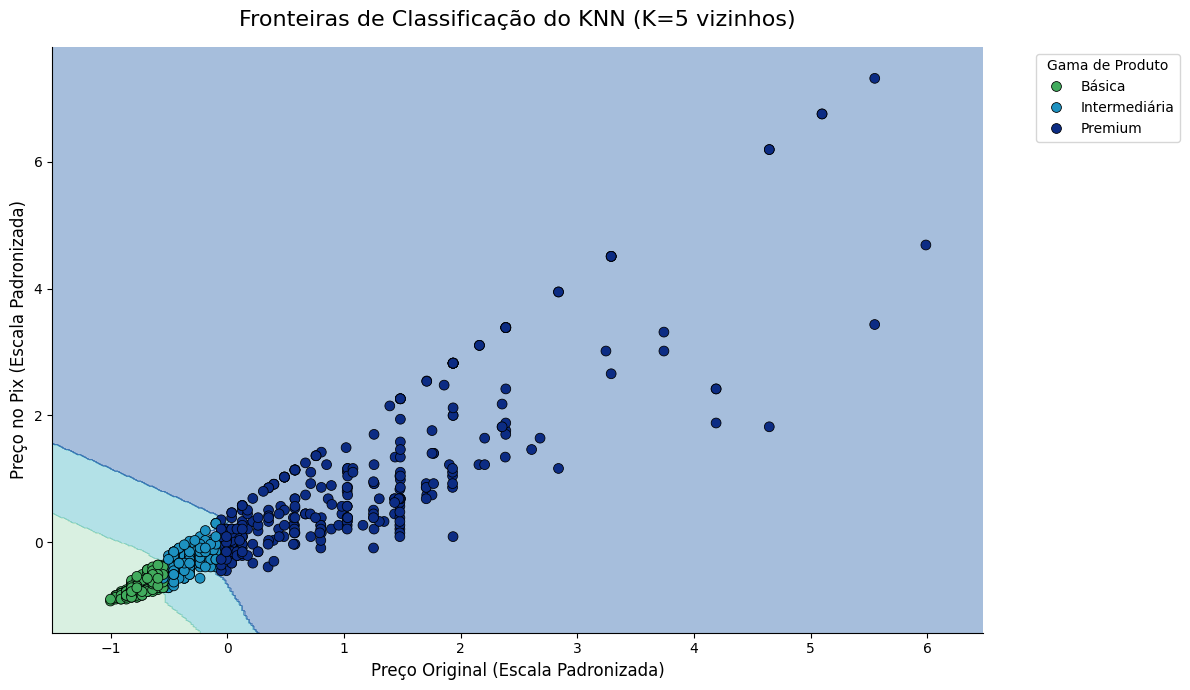

=== SIMULADOR DE CLASSIFICAÇÃO ===
Se um produto novo custar R$250.00 (Pix: R$220.00):
O algoritmo KNN classifica como Gama: -> INTERMEDIÁRIA <-


In [30]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

from matplotlib.colors import ListedColormap


warnings.filterwarnings('ignore')


# 2. Tratamento e Limpeza (Foco nos Preços)
colunas_preco = ['Preço Original', 'Preço Pix']

for col in colunas_preco:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace('R$', '', regex=False)
            df[col] = df[col].str.replace('.', '', regex=False)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove linhas vazias e pega uma amostra caso a base seja muito grande (para o gráfico não ficar pesado)
df_modelo = df.dropna(subset=colunas_preco).copy()
if len(df_modelo) > 1000:
    df_modelo = df_modelo.sample(n=1000, random_state=42)

# --- CRIAÇÃO DE DADOS SIMULADOS PARA O TREINO ---
# Como não temos uma categoria pronta, vamos criar uma "Gama de Produto" baseada em quartis
limites = df_modelo['Preço Original'].quantile([0.33, 0.66]).values
df_modelo['Gama'] = np.where(df_modelo['Preço Original'] <= limites[0], 'Básica',
                    np.where(df_modelo['Preço Original'] <= limites[1], 'Intermediária', 'Premium'))

# 3. Preparação para o Machine Learning
X = df_modelo[['Preço Original', 'Preço Pix']]
# O computador prefere números a palavras, então mapeamos as categorias
y = df_modelo['Gama'].map({'Básica': 0, 'Intermediária': 1, 'Premium': 2})

# Padronização (Essencial para o KNN medir as distâncias corretamente)
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# 4. Treinamento do Modelo KNN
k_vizinhos = 5 # Vai olhar para os 5 produtos mais próximos
knn = KNeighborsClassifier(n_neighbors=k_vizinhos)
knn.fit(X_padronizado, y)

# 5. Criação da Malha de Fundo (Para pintar as fronteiras de decisão)
passo = 0.02
x_min, x_max = X_padronizado[:, 0].min() - 0.5, X_padronizado[:, 0].max() + 0.5
y_min, y_max = X_padronizado[:, 1].min() - 0.5, X_padronizado[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, passo), np.arange(y_min, y_max, passo))

# O modelo tenta prever a categoria de cada ponto na tela
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 6. Construção do Gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Cores de fundo (As zonas de decisão)
cores_fundo = ListedColormap(['#A1DAB4', '#41B6C4', '#225EA8']) # Tons de azul/verde bem suaves
cores_pontos = ['#41AB5D', '#1D91C0', '#0C2C84'] # Cores mais fortes para os pontos reais

# Pinta o fundo da imagem de acordo com a previsão do KNN
ax.contourf(xx, yy, Z, cmap=cores_fundo, alpha=0.4)

# Desenha os produtos reais do estoque por cima
sns.scatterplot(
    data=df_modelo,
    x=X_padronizado[:, 0],
    y=X_padronizado[:, 1],
    hue='Gama',
    palette=cores_pontos,
    edgecolor='black', # Bordinha preta nas bolinhas para dar destaque
    s=50,
    ax=ax
)

ax.set_title(f'Fronteiras de Classificação do KNN (K={k_vizinhos} vizinhos)', fontsize=16, pad=15)
ax.set_xlabel('Preço Original (Escala Padronizada)', fontsize=12)
ax.set_ylabel('Preço no Pix (Escala Padronizada)', fontsize=12)

ax.legend(title='Gama de Produto', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()

# 7. Teste Prático do Modelo
print("=== SIMULADOR DE CLASSIFICAÇÃO ===")
preco_orig_teste = 250.00
preco_pix_teste = 220.00

# O novo produto precisa passar pelo mesmo scaler antes da previsão
novo_produto = scaler.transform([[preco_orig_teste, preco_pix_teste]])
previsao = knn.predict(novo_produto)[0]
categorias = {0: 'Básica', 1: 'Intermediária', 2: 'Premium'}

print(f"Se um produto novo custar R${preco_orig_teste:.2f} (Pix: R${preco_pix_teste:.2f}):")
print(f"O algoritmo KNN classifica como Gama: -> {categorias[previsao].upper()} <-")